ANDROID APP MARKET ANALYSIS - GOOGLE PLAY STORE

[STEP 1] Loading Datasets...
Apps dataset shape: (9659, 14)
Reviews dataset shape: (64295, 5)

[STEP 2] Data Cleaning & Preparation...
Data cleaned successfully

[STEP 3] Category Exploration...

Top 10 App Categories:
Category
FAMILY             1608
GAME                912
TOOLS               718
FINANCE             302
PRODUCTIVITY        301
LIFESTYLE           301
PERSONALIZATION     298
MEDICAL             290
BUSINESS            263
PHOTOGRAPHY         263
Name: count, dtype: int64


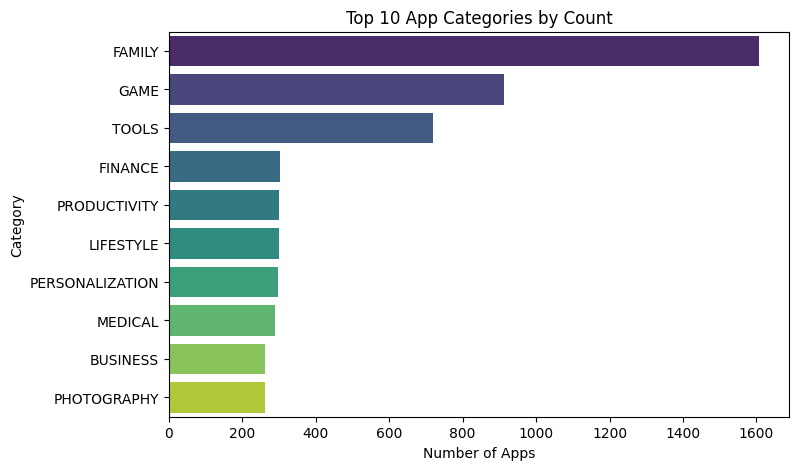


[STEP 4] Metrics Analysis...

Rating Summary:
count    8196.000000
mean        4.173243
std         0.536625
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

Pricing Distribution:
Is_Free
True     92.630551
False     7.369449
Name: proportion, dtype: float64

Most Installed Apps:
                    App    Installs
2191      Google Photos  1000000000
2002           Facebook  1000000000
152   Google Play Books  1000000000
701   Google Play Games  1000000000
2012            Google+  1000000000


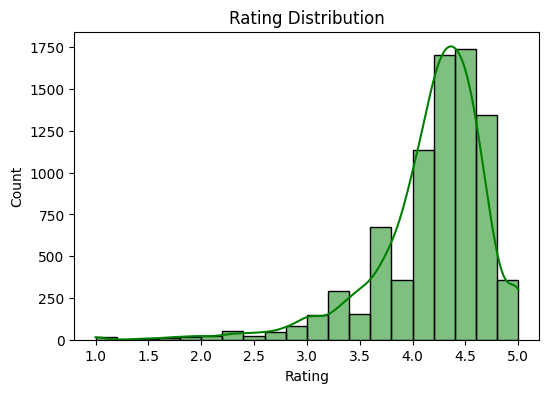


[STEP 5] Sentiment Analysis...

Sentiment Distribution:
Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64


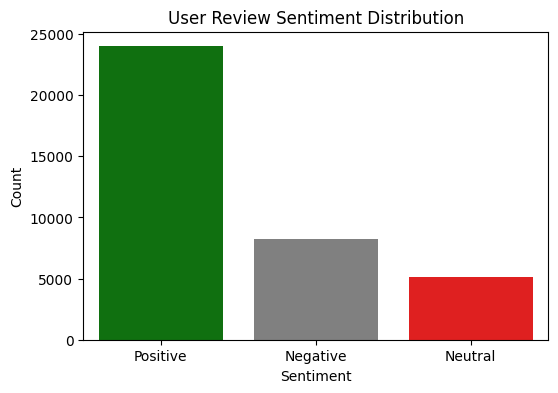


Top 5 Categories with Positive Sentiment:
Category
COMICS               0.440031
EVENTS               0.377933
AUTO_AND_VEHICLES    0.348683
PARENTING            0.318880
WEATHER              0.294978
Name: Sentiment_Polarity, dtype: float64

[STEP 6] Visual Insights...


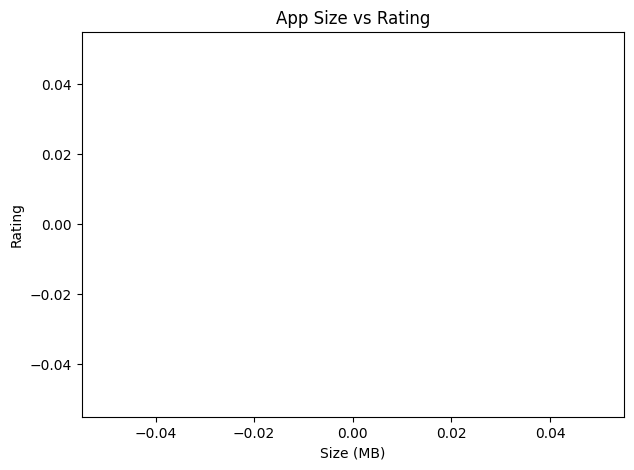

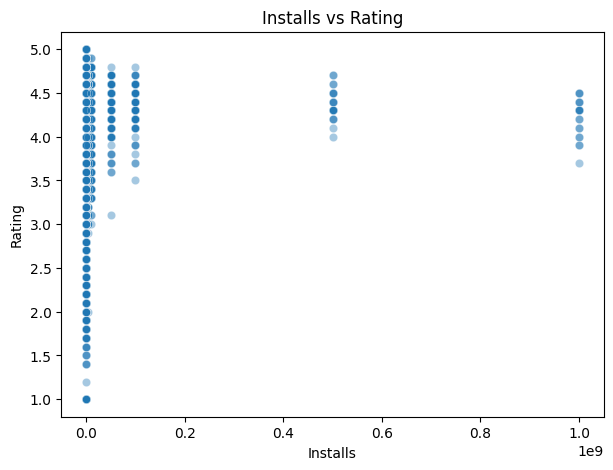


FINAL INSIGHTS & MARKET UNDERSTANDING

• Free apps dominate the Google Play Store ecosystem
• Categories like FAMILY, GAME, and TOOLS are highly saturated
• Higher ratings generally correlate with higher installs
• Smaller apps tend to receive slightly better ratings
• Positive sentiment dominates user reviews
• Sentiment analysis provides valuable feedback beyond ratings

SKILLS APPLIED:
• Data Cleaning & Preparation
• Category & Market Analysis
• Metric Evaluation (Ratings, Installs, Price)
• Sentiment Analysis
• Data Visualization & Interpretation


✓ ANDROID APP MARKET ANALYSIS COMPLETED SUCCESSFULLY!


In [2]:
# =========================================================
# Android App Market Analysis - Oasis Infobyte Internship
# Project:Google Play Store Data Analytics
#=========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("="*70)
print("ANDROID APP MARKET ANALYSIS - GOOGLE PLAY STORE")
print("="*70)

# ===============================================================
# STEP 1: DATA LOADING
# ===============================================================
print("\n[STEP 1] Loading Datasets...")

apps_df = pd.read_csv("apps.csv")
reviews_df = pd.read_csv("user_reviews.csv")

print("Apps dataset shape:", apps_df.shape)
print("Reviews dataset shape:", reviews_df.shape)

# ===============================================================
# STEP 2: DATA PREPARATION & CLEANING
# ===============================================================
print("\n[STEP 2] Data Cleaning & Preparation...")

df = apps_df.copy()

# Remove duplicates
df.drop_duplicates(subset="App", inplace=True)

# Clean Rating
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df = df[df["Rating"] <= 5]

# Clean Reviews
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

# Clean Installs
df["Installs"] = df["Installs"].str.replace("[+,]", "", regex=True)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

# Clean Price
df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Is_Free"] = df["Price"] == 0

# Clean Size
def convert_size(size):
    if "M" in str(size):
        return float(size.replace("M", ""))
    elif "k" in str(size):
        return float(size.replace("k", "")) / 1024
    else:
        return np.nan

df["Size_MB"] = df["Size"].apply(convert_size)

print("Data cleaned successfully")

# ===============================================================
# STEP 3: CATEGORY EXPLORATION
# ===============================================================
print("\n[STEP 3] Category Exploration...")

category_counts = df["Category"].value_counts()

print("\nTop 10 App Categories:")
print(category_counts.head(10))

plt.figure(figsize=(8,5))
sns.barplot(y=category_counts.head(10).index,
            x=category_counts.head(10).values,
            palette="viridis")
plt.title("Top 10 App Categories by Count")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.show()

# ===============================================================
# STEP 4: METRICS ANALYSIS
# ===============================================================
print("\n[STEP 4] Metrics Analysis...")

print("\nRating Summary:")
print(df["Rating"].describe())

print("\nPricing Distribution:")
print(df["Is_Free"].value_counts(normalize=True) * 100)

print("\nMost Installed Apps:")
print(df[["App", "Installs"]].sort_values(by="Installs", ascending=False).head(5))

plt.figure(figsize=(6,4))
sns.histplot(df["Rating"], bins=20, kde=True, color="green")
plt.title("Rating Distribution")
plt.show()

# ===============================================================
# STEP 5: SENTIMENT ANALYSIS (USER REVIEWS)
# ===============================================================
print("\n[STEP 5] Sentiment Analysis...")

sentiment_df = reviews_df.dropna(subset=["Sentiment"])

sentiment_counts = sentiment_df["Sentiment"].value_counts()
print("\nSentiment Distribution:")
print(sentiment_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index,
            y=sentiment_counts.values,
            palette=["green","gray","red"])
plt.title("User Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Average sentiment polarity per category
merged_df = sentiment_df.merge(df[["App", "Category"]], on="App", how="left")

sentiment_by_category = merged_df.groupby("Category")["Sentiment_Polarity"].mean().sort_values(ascending=False)

print("\nTop 5 Categories with Positive Sentiment:")
print(sentiment_by_category.head(5))

# ===============================================================
# STEP 6: INTERACTIVE VISUALIZATIONS
# ===============================================================
print("\n[STEP 6] Visual Insights...")

plt.figure(figsize=(7,5))
sns.scatterplot(x="Size_MB", y="Rating", data=df, alpha=0.4)
plt.title("App Size vs Rating")
plt.xlabel("Size (MB)")
plt.ylabel("Rating")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(x="Installs", y="Rating", data=df, alpha=0.4)
plt.title("Installs vs Rating")
plt.xlabel("Installs")
plt.ylabel("Rating")
plt.show()

# ===============================================================
# STEP 7: FINAL INSIGHTS & CONCLUSION
# ===============================================================
print("\n" + "="*70)
print("FINAL INSIGHTS & MARKET UNDERSTANDING")
print("="*70)

print("""
• Free apps dominate the Google Play Store ecosystem
• Categories like FAMILY, GAME, and TOOLS are highly saturated
• Higher ratings generally correlate with higher installs
• Smaller apps tend to receive slightly better ratings
• Positive sentiment dominates user reviews
• Sentiment analysis provides valuable feedback beyond ratings

SKILLS APPLIED:
• Data Cleaning & Preparation
• Category & Market Analysis
• Metric Evaluation (Ratings, Installs, Price)
• Sentiment Analysis
• Data Visualization & Interpretation
""")

print("\n✓ ANDROID APP MARKET ANALYSIS COMPLETED SUCCESSFULLY!")
